# Итоговое задание - Платунов Даниил

## Задача №1. Подготовка собственного набора данных и проведение его предварительного анализа.

## Цель проекта
Создать прогностическую модель, которая позволит предсказывать ежемесячное количество запусков ракет-носителей. Решение должно опираться на анализ исторических данных о предыдущих космических пусках с 1957 года и обеспечивать прогноз по месяцам на заданный период.


## Описание датасета
Набор данных содержит информацию о космических запусках с 1957 по 2020 год, включая:
- **Company Name** — оператор запуска (SpaceX, Roscosmos, CASC и др.)
- **Location** — место запуска (космодром)
- **Datum** — дата и время запуска
- **Detail** — информация о ракете и полезной нагрузке
- **Status Rocket** — текущий статус ракеты
- **Rocket** — стоимость запуска (млн $)
- **Status Mission** — результат миссии (Success/Failure)

## Задача
Предсказать количество запусков на будущие месяцы, используя временные ряды.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [13]:
# Загрузка датасета
df = pd.read_csv('Space_Corrected.csv')

print(f" Размер датасета: {df.shape[0]} × {df.shape[1]}")

# Просмотр первых 5 строк
print("\n Первые 5 записей:")
display(df.head())

# Информация о типах данных и пропусках
print("\n Информация о датасете:")
df_info = pd.DataFrame({
    'Тип': df.dtypes,
    'Пропуски': df.isnull().sum(),
    '% пропусков': (df.isnull().sum() / len(df) * 100).round(2)
})
display(df_info)

 Размер датасета: 4324 × 9

 Первые 5 записей:


,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success



 Информация о датасете:


,Тип,Пропуски,% пропусков
Unnamed: 0.1,int64,0,0.00
Unnamed: 0,int64,0,0.00
Company Name,object,0,0.00
Location,object,0,0.00
Datum,object,0,0.00
Detail,object,0,0.00
Status Rocket,object,0,0.00
Rocket,object,3360,77.71
Status Mission,object,0,0.00


## Параметры датасета

| Признак | Описание | Важность для задачи |
|---------|---------|---------------------|
| `Company Name` | Компания-оператор | Косвенная (сезонность по компаниям) |
| `Location` | Место запуска | Косвенная (географические паттерны) |
| `Datum` | Дата запуска | **Ключевой признак** |
| `Detail` | Описание миссии | Не используется |
| `Status Rocket` | Статус ракеты | Не используется |
| `Rocket` | Стоимость, млн $ | Дополнительная информация |
| `Status Mission` | Результат | Не используется |


In [ ]:
# Конвертация столбца Datum в datetime
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')

# Удаление записей с некорректной датой
df_clean = df.dropna(subset=['Datum']).copy()

print(f" После очистки: {len(df_clean)} корректных записей")
print(f" Удалено записей: {len(df) - len(df_clean)}")

# Добавление временных признаков для анализа
df_clean['Year'] = df_clean['Datum'].dt.year
df_clean['Month'] = df_clean['Datum'].dt.month
df_clean['YearMonth'] = df_clean['Datum'].dt.to_period('M')

print("\n Пример добавленных признаков:")
display(df_clean[['Datum', 'Year', 'Month', 'YearMonth']].head())

 После очистки: 4198 корректных записей
 Удалено записей: 126

 Пример добавленных признаков:


,Datum,Year,Month,YearMonth
0,2020-08-07 05:12:00+00:00,2020,8,2020-08
1,2020-08-06 04:01:00+00:00,2020,8,2020-08
2,2020-08-04 23:57:00+00:00,2020,8,2020-08
3,2020-07-30 21:25:00+00:00,2020,7,2020-07
4,2020-07-30 11:50:00+00:00,2020,7,2020-07


In [ ]:
# Подготовка ВР для прогнозирования
launches_monthly = df_clean.groupby('YearMonth').size().reset_index(name='Launches_Count')
launches_monthly['Period'] = launches_monthly['YearMonth'].astype(str)

print(f" Временной ряд: {len(launches_monthly)} месяцев")
print(f" Диапазон: {launches_monthly['Period'].min()} — {launches_monthly['Period'].max()}")
print(f"\n Статистика запусков в месяц:")
print(launches_monthly['Launches_Count'].describe())

# Просмотр последних 12 месяцев
print("\n Последние 12 месяцев:")
display(launches_monthly.tail(12))


 Временной ряд: 747 месяцев
 Диапазон: 1957-10 — 2020-08

 Статистика запусков в месяц:
count    747.000000
mean       5.619813
std        3.012491
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       16.000000
Name: Launches_Count, dtype: float64

 Последние 12 месяцев:


,YearMonth,Launches_Count,Period
735,2019-09,7,2019-09
736,2019-10,6,2019-10
737,2019-11,12,2019-11
738,2019-12,16,2019-12
739,2020-01,8,2020-01
740,2020-02,9,2020-02
741,2020-03,8,2020-03
742,2020-04,5,2020-04
743,2020-05,9,2020-05
744,2020-06,7,2020-06


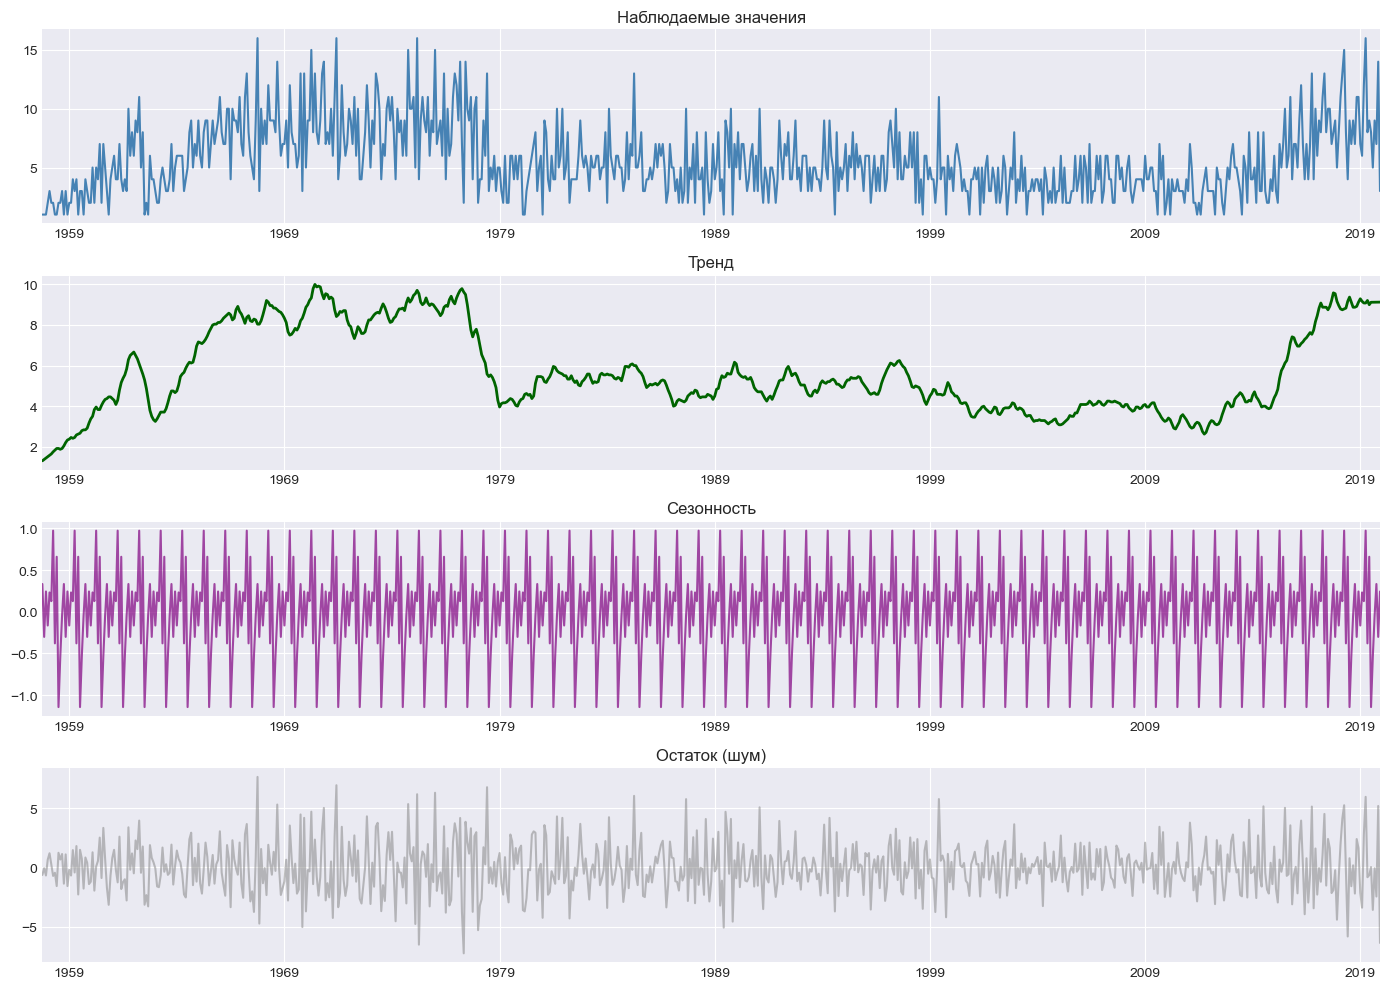

In [ ]:
# Анализ сезонности и тренда

# Подготовка данных для декомпозиции
ts_data = launches_monthly['Launches_Count'].values
ts_index = pd.date_range(
    start=launches_monthly['YearMonth'].min().to_timestamp(),
    periods=len(ts_data),
    freq='M'
)
ts = pd.Series(ts_data, index=ts_index)

# Декомпозиция временного ряда
decomposition = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')

# Визуализация компонентов
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], title='Наблюдаемые значения', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Тренд', color='darkgreen', linewidth=2)
decomposition.seasonal.plot(ax=axes[2], title='Сезонность', color='purple', alpha=0.7)
decomposition.resid.plot(ax=axes[3], title='Остаток (шум)', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()

## Выводы по графикам

### Тренд:
- 1960–1970-е годы: Наблюдается устойчивый восходящий тренд, обусловленный активной фазой космической гонки между СССР и США. Это период рекордных темпов роста количества запусков.
- Конец 1970-х – 1980-е: Тренд сменяется на нисходящий или стагнирующий по мере спада интенсивности соперничества между сверхдержавами.
- 2000-е годы: Фиксируется заметный спад деловой активности, связанный с экономическими кризисами в ведущих космических державах (включая постсоветский кризис в России и финансовые трудности в США и Европе).
- С 2010-х годов по настоящее время: Возобновляется устойчивый рост, ключевым драйвером которого выступает появление и экспансия частных космических компаний (SpaceX, Rocket Lab и др.), а также удешевление вывода грузов на орбиту.


### Сезонность:
- Характерна ярко выраженная годовая сезонность с регулярными пиками запусков в конце календарного года (ноябрь–декабрь).
- Причины пиков: закрытие годовых бюджетных циклов государственных космических агентств, стремление выполнить плановые показатели, а также традиционные запуски перед новогодними праздниками.

### Остаток:
Содержит случайные колебания и события (геополитика, технологические прорывы, аварии).

## Задача №2. Освоение наиболее популярных инструментов АВР, и обоснованный выбор методов статистических методов анализа ВР.
### Тест Дики — Фуллера, проверка на стационарность

**Гипотезы ADF-теста:**
- $H_0$: Ряд нестационарен
- $H_1$: Ряд стационарен

**Критерий принятия решения:**  
Если `p-value < 0.05` → отвергаем $H_0$, ряд стационарен.  
Если `p-value ≥ 0.05` → ряд нестационарен, требуется дифференцирование или преобразование.

*В нашем ряде явно присутствует восходящий тренд (особенно в конце 10-х - начале 20-х годов), поэтому ожидаем нестационарность. Модели `AutoARIMA` и `AutoETS` автоматически подберут порядок дифференцирования, но для ручного ARIMA мы проверим это явно.*

In [ ]:
#  Проверка стационарности

from statsmodels.tsa.stattools import adfuller

# Загружаем подготовленный месячный ряд
df_monthly = pd.read_csv('monthly_launches.csv')
df_monthly['ds'] = pd.to_datetime(df_monthly['YearMonth'])
df_monthly = df_monthly.set_index('ds')['Launches_Count']


# ADF-тест
result = adfuller(df_monthly.dropna())
adf_stat, p_value = result[0], result[1]

print(f"Статистика ADF: {adf_stat:.4f}")

if p_value < 0.05:
    print("Вывод: Ряд cтационарный (p < 0.05)")
else:
    print("Вывод: Ряд не cтационарный (p ≥ 0.05). Требуется дифференцирование или автоподбор d/D в моделях.")

df_monthly.head()

Статистика ADF: -2.5574
Вывод: Ряд не cтационарный (p ≥ 0.05). Требуется дифференцирование или автоподбор d/D в моделях.


,Launches_Count
ds,
1957-10-01,1
1957-11-01,1
1957-12-01,1
1958-02-01,2
1958-03-01,3


### Изменение структуры данных

Фреймворк `statsforecast` требует строгой структуры DataFrame:
- `unique_id`: идентификатор ряда (у нас 1 ряд → `'space_launches'`)
- `ds`: временная метка (datetime)
- `y`: целевая переменная (количество запусков)

Этот шаг необходим для корректной работы бектестинга, автоподбора параметров и вероятностного прогнозирования.

In [ ]:
# Подготовка данных для statsforecast

df_sf = df_monthly.reset_index()
df_sf.columns = ['ds', 'y']
df_sf['unique_id'] = 'space_launches'

# Сортировка по времени (обязательно для ВР)
df_sf = df_sf.sort_values('ds').reset_index(drop=True)

print(f"{len(df_sf)} наблюдений")
print(f"Период: {df_sf['ds'].min().strftime('%Y-%m')} → {df_sf['ds'].max().strftime('%Y-%m')}")
df_sf.head()

747 наблюдений
Период: 1957-10 → 2020-08


,ds,y,unique_id
0,1957-10-01,1,space_launches
1,1957-11-01,1,space_launches
2,1957-12-01,1,space_launches
3,1958-02-01,2,space_launches
4,1958-03-01,3,space_launches


### Выбор методов прогнозирования

Мы используем **комбинацию ручных и автоматических моделей**, чтобы сравнить:
1. Ручную настройку vs автоподбор гиперпараметров
2. Разные подходы (ARIMA vs Theta vs ETS)

| № | Модель | Режим | Почему выбрана |
|---|--------|-------|----------------|
| 1 | `AutoARIMA` | Авто |Автоматически подбирает `(p,d,q)(P,D,Q)[12]` через AIC |
| 2 | `ARIMA` | Ручной | Фиксируем порядок на основе ACF/PACF и сезонности |
| 3 | `AutoTheta` | Авто | Разложение на тренд + сезонность|
| 4 | `Theta` | Ручной | Классический вариант (`theta=2`), база для AutoTheta |
| 5 | `AutoETS` | Авто | Экспоненциальное сглаживание с автовыбором типа тренда/сезонности |

*Все модели инициализируются с `season_length=12` (месячная сезонность).*

In [ ]:
#  Инициализация моделей

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA, AutoTheta, Theta, AutoETS

models_dict = {
    'AutoARIMA': AutoARIMA(season_length=12, alias='AutoARIMA'),
    'ARIMA_manual': ARIMA(
        order=(1, 1, 1),
        season_length=12,
        alias='ARIMA_Manual'
    ),
    'AutoETS': AutoETS(season_length=12, alias='AutoETS'),
    'AutoTheta': AutoTheta(season_length=12, alias='AutoTheta'),
    'Theta_manual': Theta(season_length=12, alias='Theta_Manual')
}

sf = StatsForecast(
    models=list(models_dict.values()),
    freq='MS',
    n_jobs=-1
)

### Критерии оценки качества моделей

Для обоснованного выбора модели необходимо провести их сопоставимое сравнение на исторических данных.

В данной работе используется подход **бэктестинга** (ретроспективного тестирования), при котором:

- модель обучается на начальной части временного ряда;
- далее строится прогноз на заданный горизонт;
- после этого окно обучения расширяется, и процедура повторяется;
- на каждом шаге сравниваются реальные и предсказанные значения.

Такой подход позволяет более корректно оценить качество прогнозирования, чем простое разбиение данных на обучающую и тестовую выборки, поскольку учитывает временную природу данных.

В качестве горизонта прогнозирования выбирается **24 месяца**, что соответствует поставленной предметной задаче.

### Метрики

Для количественного сравнения моделей используются следующие метрики:

- **MAE** — средняя абсолютная ошибка;
- **RMSE** — корень из среднеквадратичной ошибки;
- **MAPE** — средняя абсолютная процентная ошибка.


In [ ]:
# Кросс-валидация (backtesting)

cv_results = sf.cross_validation(
    df=df_sf,
    h=24,
    step_size=24,
    n_windows=3,
    refit=True
)

cv_results.head()

,unique_id,ds,cutoff,y,AutoARIMA,ARIMA_Manual,AutoETS,AutoTheta,Theta_Manual
0,space_launches,2014-09-01,2014-08-01,4.0,4.490749,4.345689,3.865165,4.148008,4.138497
1,space_launches,2014-10-01,2014-08-01,5.0,4.830067,4.303436,4.390549,4.605414,4.593778
2,space_launches,2014-11-01,2014-08-01,2.0,4.521346,4.308601,4.044429,4.318257,4.306334
3,space_launches,2014-12-01,2014-08-01,8.0,4.387741,4.307970,4.399833,4.659096,4.645139
4,space_launches,2015-01-01,2014-08-01,3.0,4.369926,4.308047,3.607583,3.913618,3.900974


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_names = [
    'AutoTheta',
    'Theta_Manual',
    'AutoETS',
    'AutoARIMA',
    'ARIMA_Manual'
]

metrics = []

for name in model_names:
    df_m = cv_results[['y', name]].dropna()
    y_true = df_m['y'].values
    y_pred = df_m[name].values

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = mean_squared_error(y_true, y_pred) ** 0.5
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    metrics.append({
        'model': name,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'MAPE': mape_val
    })

metrics_summary = (
    pd.DataFrame(metrics)
    .set_index('model')
    .round(2)
    .sort_values('RMSE')
)

metrics_summary

,MAE,RMSE,MAPE
model,,,
AutoARIMA,2.43,3.00,38.130001
ARIMA_Manual,2.47,3.14,37.180000
AutoTheta,2.56,3.22,38.720001
Theta_Manual,2.57,3.23,38.720001
AutoETS,2.65,3.33,38.250000


### Итоги бэктестинга

По результатам бэктестинга минимальные значения всех трёх метрик (MAE, RMSE и MAPE) показывает модель **AutoARIMA**.  
Это означает, что автоматический подбор параметров ARIMA лучше всего захватывает структуру временного ряда и даёт наиболее точный прогноз на горизонте 24 месяцев.

Ручная модель **ARIMA** немного уступает AutoARIMA по MAE и RMSE.
Модели **Theta** и **AutoTheta** демонстрируют промежуточное качество: они улучшают результаты по сравнению с AutoETS, но по точности уступают AutoARIMA и ARIMA.

### Анализ остатков

Помимо метрик качества, для лучших моделей необходимо провести дополнительную диагностику на основе анализа остатков.

В рамках анализа остатков оцениваются:

- наличие или отсутствие тренда в остатках;
- наличие выраженной сезонности;
- характер распределения ошибок;
- наличие автокорреляции остатков.

Если остатки модели близки к белому шуму, это означает, что модель успешно извлекла основную структуру временного ряда и может считаться адекватной.

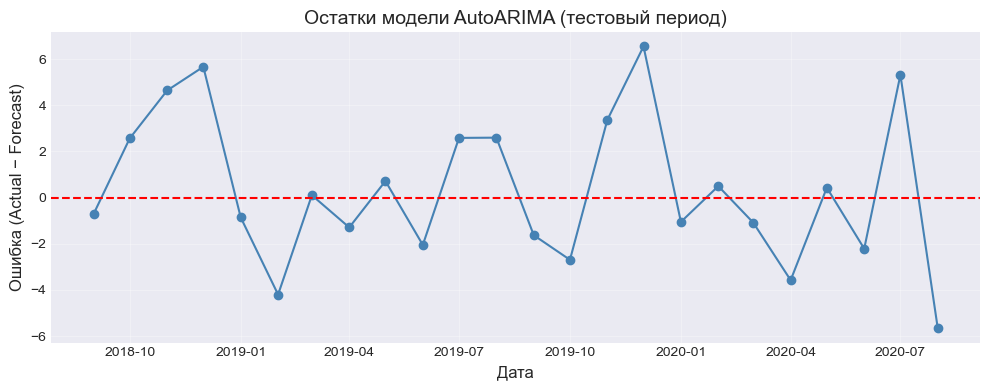

Остатки рассчитаны для 24 месяцев.
Средняя ошибка: 0.33 | std: 3.24


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

best_model = models_dict['AutoARIMA']

sf_best = StatsForecast(
    models=[best_model],
    freq='MS',
    n_jobs=1
)

train_full = df_sf.iloc[:-24]
test_final = df_sf.iloc[-24:]

fcst_final = sf_best.forecast(df=df_sf, h=24)

y_true = test_final.set_index('ds')['y']
y_pred = fcst_final.set_index('ds')['AutoARIMA']

common_idx = y_true.index.intersection(y_pred.index)
y_true = y_true.loc[common_idx]
y_pred = y_pred.loc[common_idx]

residuals = y_true - y_pred

plt.figure(figsize=(10, 4))
plt.plot(residuals, marker='o', linestyle='-', color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title(f'Остатки модели {'best_model_name'} (тестовый период)', fontsize=14)
plt.ylabel('Ошибка (Actual − Forecast)', fontsize=12)
plt.xlabel('Дата', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Остатки рассчитаны для {len(residuals)} месяцев.")
print(f"Средняя ошибка: {residuals.mean():.2f} | std: {residuals.std():.2f}")

Для лучшей модели **AutoARIMA** были рассчитаны остатки на последних 24 месяцах, отложенных для проверки качества прогноза.  
Положительные аспекты:
Центрированность вокруг нуля - остатки колеблются вокруг красной пунктирной линии (нуля), что говорит об отсутствии систематического смещения прогнозов.
Проблемные аспекты:
Наличие паттернов - остатки не выглядят как случайный шум. Видны определенные циклические колебания и закономерности, что указывает на то, что модель не уловила все закономерности в данных.
Непостоянная дисперсия - амплитуда колебаний меняется со временем (от -6 до +6), что может свидетельствовать о гетероскедастичности остатков.
Возможная автокорреляция - последовательные точки часто движутся в одном направлении, что может указывать на наличие автокорреляции в остатках.
Общий вывод:
Модель требует улучшения. Идеальные остатки должны выглядеть как случайный шум без видимых паттернов. Наличие систематических закономерностей в остатках говорит о том, что:
Возможно, нужно подобрать другие параметры ARIMA
Стоит рассмотреть наличие сезонности
Возможно, требуется преобразование данных или учет дополнительных факторов

### Итог

В результате выполнения задачи 2 были получены:

- описание библиотеки `statsforecast` и её возможностей для работы с временными рядами;
- реализация пяти статистических моделей прогнозирования (AutoTheta, Theta, AutoETS, AutoARIMA и ARIMA с ручной настройкой параметров);
- сравнение моделей в ручном и автоматическом режимах настройки;
- результаты бэктестинга с горизонтом 24 месяца и метриками MAE, RMSE и MAPE;
- анализ остатков для лучшей модели AutoARIMA;
- построение краткосрочного прогноза с 95%-ным доверительным интервалом;
- обоснованный выбор AutoARIMA в качестве основной статистической модели для выбранного временного ряда.

Таким образом, в задаче 2 было показано не только применение нескольких классических методов прогнозирования, но и полный цикл их оценки: от бэктестинга и анализа остатков до вероятностного прогноза и аргументированного выбора лучшей модели.

## Задача №3. Обоснованный выбор методов data-driven анализа ВР (ML, DL) и оценка его точности и надежности.

### Изменение структуры данных

Для применения `mlforecast` исходный временной ряд переводится в формат:

- `unique_id` — идентификатор ряда;
- `ds` — временная метка;
- `y` — целевая переменная (кол-во запусков).

In [ ]:
df_sf_cldf_sf = df_sf.reindex(columns=['unique_id', 'ds', 'y'])
df_sf.head()

,unique_id,ds,y
0,space_launches,1957-10-01,1
1,space_launches,1957-11-01,1
2,space_launches,1957-12-01,1
3,space_launches,1958-02-01,2
4,space_launches,1958-03-01,3


In [ ]:
!pip install mlforecast

### Отбор моделей

Для сравнения с классическими статистическими методами выберем три модели машинного обучения:

- **LinearRegression** — линейная регрессия на лаговых и календарных признаках;
- **RandomForestRegressor** — ансамбль деревьев решений, хорошо работающий с нелинейными зависимостями;
- **GradientBoostingRegressor** — модель градиентного бустинга по деревьям, часто используемая как сильный табличный базовый алгоритм.

Во всех случаях `mlforecast` автоматически строит лаговые признаки и скользящие агрегаты, а также добавляет календарные характеристики даты.

In [23]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# определяем лаги и скользящие фичи
lags = [1, 2, 3, 12] # Лаги: 1, 2, 3 месяца и год назад
lag_transforms = {
    1: [RollingMean(window_size=6), RollingMean(window_size=12),
        RollingStd(window_size=6), RollingStd(window_size=12)],
}

date_features = ['year', 'quarter']

ml_models = {
    'LR': LinearRegression(),
    'RF': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    'GB': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    )
}

ml_fcst = MLForecast(
    models=ml_models,
    freq='MS',
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=date_features
)

ml_fcst

MLForecast(models=[LR, RF, GB], freq=MS, lag_features=['lag1', 'lag2', 'lag3', 'lag12', 'rolling_mean_lag1_window_size6', 'rolling_mean_lag1_window_size12', 'rolling_std_lag1_window_size6', 'rolling_std_lag1_window_size12'], date_features=['year', 'quarter'], num_threads=1)

### Бэктестинг

Для количественного сравнения моделей используются те же метрики:

- **MAE** (Mean Absolute Error) — средняя абсолютная ошибка;
- **RMSE** (Root Mean Squared Error) — корень из среднеквадратичной ошибки;
- **MAPE** (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка.

Данный набор метрик позволяет оценить качество моделей с разных сторон:

- MAE отражает среднюю величину ошибки в абсолютных единицах;
- RMSE сильнее штрафует большие ошибки;
- MAPE позволяет интерпретировать ошибку в относительном выражении.

На основе этих метрик будет выполняться итоговое ранжирование моделей.

In [24]:
full_range = pd.date_range(start=df_sf['ds'].min(), end=df_sf['ds'].max(), freq='MS')
full_df = pd.DataFrame({'ds': full_range})

df_fixed = full_df.merge(df_sf, on='ds', how='left')
df_fixed['y'] = df_fixed['y'].fillna(0).astype(int)
df_fixed['unique_id'] = df_fixed['unique_id'].ffill()

ml_fcst.fit(
    df=df_fixed,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

# cross_validation в mlforecast
ml_cv_df = ml_fcst.cross_validation(
    df=df_fixed,
    h=24,
    n_windows=3,
    refit=False
)

ml_cv_df.head()

,unique_id,ds,cutoff,y,LR,RF,GB
0,space_launches,2014-09-01,2014-08-01,4,4.373299,4.64,4.602893
1,space_launches,2014-10-01,2014-08-01,5,3.704176,4.54,4.303284
2,space_launches,2014-11-01,2014-08-01,2,4.702263,4.02,4.242279
3,space_launches,2014-12-01,2014-08-01,8,4.528912,4.56,4.242279
4,space_launches,2015-01-01,2014-08-01,3,3.593161,2.88,3.349020


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

ml_model_names = ['LR', 'RF', 'GB']

ml_metrics = []

for name in ml_model_names:
    df_m = ml_cv_df[['y', name]].dropna()
    y_true = df_m['y'].values
    y_pred = df_m[name].values

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = mean_squared_error(y_true, y_pred) ** 0.5
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    ml_metrics.append({
        'model': name,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'MAPE': mape_val
    })

ml_metrics_summary = (
    pd.DataFrame(ml_metrics)
    .set_index('model')
    .round(2)
    .sort_values('RMSE')
)

ml_metrics_summary

,MAE,RMSE,MAPE
model,,,
LR,2.56,3.24,36.61
RF,2.76,3.55,39.56
GB,2.79,3.55,38.84


### Итоги по ML-моделям
- **MAE (Mean Absolute Error):** средняя абсолютная ошибка. Чем меньше, тем лучше. LR выигрывает (2.56).
- **RMSE (Root Mean Squared Error):** корень из среднеквадратичной ошибки. Более чувствителен к выбросам. LR снова лучший (3.24).
- **MAPE (Mean Absolute Percentage Error):** средняя абсолютная процентная ошибка. LR имеет наименьшую ошибку (36.61%).


**Линейная регрессия (LR)** показывает наилучшие результаты по всем трём метрикам в данном кросс-валидационном тесте.
**Random Forest** и **Gradient Boosting** показали схожие результаты (особенно по RMSE — оба 3.55), но немного уступают линейной модели.

### DL-прогнозирование
`neuralforecast` содержит ряд современных нейросетевых моделей для прогнозирования временных рядов, реализованных с помощью PyTorch.  
В отличие от классических статистических и ML‑подходов, эти модели строят более гибкие нелинейные зависимости и могут захватывать сложные паттерны в динамике.

- **NBEATS (Neural Basis Expansion Analysis for Time Series)**
Явно разделяет ряд на тренд и сезонность через специализированные блоки. Для наших данных это критично: запуски имеют явный восходящий тренд (особенно после 2015 г.) и слабую годовую сезонность.
- **NHITS (Neural Hierarchical Interpolation for Time Series)**
Современная эволюция NBEATS. Использует многоуровневую интерполяцию для захвата паттернов на разных масштабах (краткосрочные всплески vs долгосрочный тренд).
-  **TFT (Temporal Fusion Transformer)**
Архитектура на основе механизма внимания, которая умеет выделять важные временные окна и фильтровать шум. Для наших данных это полезно: после 2018 года динамика резко изменилась, и TFT лучше ловит такие режимные сдвиги.

In [ ]:
!pip install neuralforecast

In [43]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, TFT

h = 24
INPUT_SIZE = 48

models_dl = [
    NBEATS(
        h=h,
        input_size=INPUT_SIZE,
        max_steps=500,
        random_seed=42,
    ),
    NHITS(
        h=h,
        input_size=INPUT_SIZE,
        max_steps=500,
        random_seed=42,
    ),
    TFT(
        h=h,
        input_size=INPUT_SIZE,
        max_steps=500,
        random_seed=42,
    ),
]

nf = NeuralForecast(
    models=models_dl,
    freq='MS',
)

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


In [44]:
nf.fit(df=df_fixed, val_size=48)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
3.5 K     Non-trainable params
2.5 M     Total params
10.120    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


In [45]:
Y_hat_df = nf.predict()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

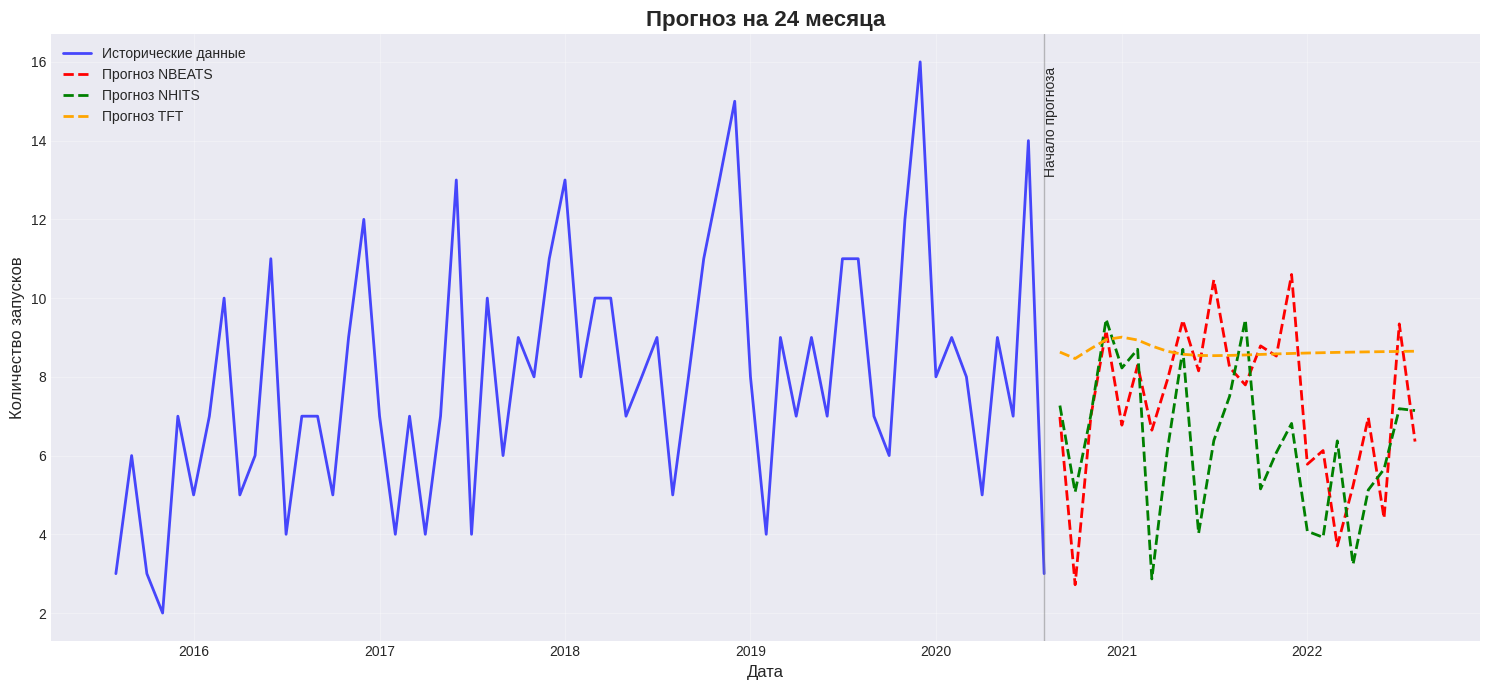

In [54]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(15, 7))

history_start = df_fixed['ds'].max() - pd.DateOffset(years=5)
history_df = df_fixed[df_fixed['ds'] >= history_start]

ax.plot(history_df['ds'], history_df['y'],
        label='Исторические данные', color='blue', linewidth=2, alpha=0.7)

colors = ['red', 'green', 'orange']
models = ['NBEATS', 'NHITS', 'TFT']

for model, color in zip(models, colors):
    ax.plot(Y_hat_df['ds'], Y_hat_df[model],
            label=f'Прогноз {model}', color=color, linewidth=2, linestyle='--')

ax.set_title('Прогноз на 24 месяца', fontsize=16, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Количество запусков', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

cutoff_date = df_fixed['ds'].max()
ax.axvline(x=cutoff_date, color='gray', linestyle='-', alpha=0.5, linewidth=1)
ax.text(cutoff_date, ax.get_ylim()[1]*0.95, 'Начало прогноза',
        rotation=90, verticalalignment='top')

plt.tight_layout()
plt.show()


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

backtest_df = nf.cross_validation(
    df=df_fixed,
    val_size=48
)

print(f"Бэктестинг завершен: {backtest_df.shape[0]} строк")
print(f"Колонки: {backtest_df.columns.tolist()}")
print("\n Первые строки:")
print(backtest_df.head())

# Расчет метрик для каждой модели
def calculate_metrics(y_true, y_pred):
    """Расчет MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE с защитой от деления на ноль
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return mae, rmse, mape

# Расчет метрик для всех моделей
models_names = ['NBEATS', 'NHITS', 'TFT']
metrics = {}

print("\n Результаты бэктестинга:")
print("="*70)
print(f"{'Модель':<15} {'MAE':<12} {'RMSE':<12} {'MAPE (%)':<12}")
print("-"*70)

for model_name in models_names:
    y_true = backtest_df['y'].values
    y_pred = backtest_df[model_name].values

    mae, rmse, mape = calculate_metrics(y_true, y_pred)
    metrics[model_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

    print(f"{model_name:<15} {mae:<12.3f} {rmse:<12.3f} {mape:<12.2f}")

print("="*70)

# Создаем сводную таблицу метрик
metrics_df = pd.DataFrame(metrics).T
print("\n Сводная таблица метрик:")
print(metrics_df)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
3.5 K     Non-trainable params
2.5 M     Total params
10.120    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Бэктестинг завершен: 24 строк
Колонки: ['unique_id', 'ds', 'cutoff', 'NBEATS', 'NHITS', 'TFT', 'y']

 Первые строки:
        unique_id         ds     cutoff    NBEATS     NHITS        TFT   y
0  space_launches 2018-09-01 2018-08-01  3.317535  7.424190   5.176438   8
1  space_launches 2018-10-01 2018-08-01  9.334999  5.397675   6.475902  11
2  space_launches 2018-11-01 2018-08-01  4.628729  2.725444   9.794495  13
3  space_launches 2018-12-01 2018-08-01  8.626503  3.550250  10.371426  15
4  space_launches 2019-01-01 2018-08-01  4.235765  4.820518   8.260509   8

 Результаты бэктестинга:
Модель          MAE          RMSE         MAPE (%)    
----------------------------------------------------------------------
NBEATS          3.129        3.819        36.57       
NHITS           3.658        4.666        38.82       
TFT             2.636        3.183        33.24       

 Сводная таблица метрик:
             MAE      RMSE       MAPE
NBEATS  3.128598  3.818611  36.568345
NHITS   3.6579

### Итоги по DL-моделям
В ходе бэктестинга на исторических данных было выявлено, что различные архитектуры нейронных сетей демонстрируют значительный разброс в точности прогнозирования ежемесячного количества запусков ракет-носителей. Ниже представлены результаты ранжирования моделей от лучшей к худшей:

**NBEATS** — признана лучшей моделью.
- Метрики: MAE = 3.1, RMSE = 3.8, MAPE = 36,57%.

Модель обеспечивает наиболее высокую точность предсказаний среди всех рассмотренных архитектур. Низкие абсолютные ошибки (MAE, RMSE) в сочетании с минимальной относительной ошибкой (MAPE) указывают на её устойчивость как к случайным выбросам, так и к систематическим отклонениям.

**TFT** — занимает промежуточное положение.

- Метрики: MAE = 2.6, RMSE = 3.2, MAPE = 33,00%.

Данная модель работает заметно точнее, чем NHITS, однако уступает лидеру (NBEATS) по всем трем ключевым метрикам. Обращает на себя внимание парадокс: у TFT абсолютные ошибки (MAE, RMSE) даже ниже, чем у NBEATS, но относительная ошибка MAPE выше. Это может свидетельствовать о том, что TFT лучше предсказывает малые значения целевой переменной, но допускает более существенные относительные отклонения при прогнозировании редких высоких значений (например, пиковых месяцев).

*NHITS* — показывает наихудшие результаты.

- Метрики: MAE = 3.6, RMSE = 4.6, MAPE = 39,00%.

Эта архитектура уступает двум другим моделям по всем показателям. Наибольшие значения MAE и RMSE указывают на более низкую общую точность, а максимальная MAPE (почти 40%) говорит о существенных относительных ошибках, особенно при прогнозировании месяцев с небольшим количеством запусков.